In [9]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## West Africa Solar Analysis

In [10]:
west_african_cities = {
    # Nigeria — 3 cities (coastal, savanna, Sahel)
    "Lagos":        {"lat": 6.5244,  "lon": 3.3792,   "country": "Nigeria",       "climate_zone": "Coastal Humid"},
    "Abuja":        {"lat": 9.0765,  "lon": 7.3986,   "country": "Nigeria",       "climate_zone": "Savanna"},
    "Kano":         {"lat": 12.0022, "lon": 8.5920,   "country": "Nigeria",       "climate_zone": "Sahel"},
    # One city per remaining country
    "Accra":        {"lat": 5.6037,  "lon": -0.1870,  "country": "Ghana",         "climate_zone": "Coastal Humid"},
    "Dakar":        {"lat": 14.7167, "lon": -17.4677, "country": "Senegal",       "climate_zone": "Sahel"},
    "Abidjan":      {"lat": 5.3600,  "lon": -4.0083,  "country": "Cote d'Ivoire", "climate_zone": "Coastal Humid"},
    "Bamako":       {"lat": 12.6392, "lon": -8.0029,  "country": "Mali",          "climate_zone": "Sahel"},
    "Ouagadougou":  {"lat": 12.3647, "lon": -1.5332,  "country": "Burkina Faso",  "climate_zone": "Sahel"},
    "Niamey":       {"lat": 13.5137, "lon": 2.1098,   "country": "Niger",         "climate_zone": "Sahel"},
    "Conakry":      {"lat": 9.6412,  "lon": -13.5784, "country": "Guinea",        "climate_zone": "Coastal Humid"},
    "Lome":         {"lat": 6.1375,  "lon": 1.2123,   "country": "Togo",          "climate_zone": "Coastal Humid"},
    "Cotonou":      {"lat": 6.3654,  "lon": 2.4183,   "country": "Benin",         "climate_zone": "Coastal Humid"},
    "Freetown":     {"lat": 8.4657,  "lon": -13.2317, "country": "Sierra Leone",  "climate_zone": "Coastal Humid"},
    "Monrovia":     {"lat": 6.2907,  "lon": -10.7605, "country": "Liberia",       "climate_zone": "Coastal Humid"},
    "Nouakchott":   {"lat": 18.0735, "lon": -15.9582, "country": "Mauritania",    "climate_zone": "Desert/Arid"},
    "Banjul":       {"lat": 13.4549, "lon": -16.5790, "country": "Gambia",        "climate_zone": "Sahel"},
    "Bissau":       {"lat": 11.8636, "lon": -15.5977, "country": "Guinea-Bissau", "climate_zone": "Coastal Humid"},
    "Praia":        {"lat": 14.9331, "lon": -23.5133, "country": "Cape Verde",    "climate_zone": "Desert/Arid"},
}

print(f"Total cities      : {len(west_african_cities)}")
print(f"Countries         : {len(set(c['country'] for c in west_african_cities.values()))}")
print(f"Climate zones     : {len(set(c['climate_zone'] for c in west_african_cities.values()))}")
print(f"\nClimate zone breakdown:")
zones = {}
for c in west_african_cities.values():
    zones[c['climate_zone']] = zones.get(c['climate_zone'], 0) + 1
for zone, count in sorted(zones.items()):
    print(f"  {zone}: {count} cities")

Total cities      : 18
Countries         : 16
Climate zones     : 4

Climate zone breakdown:
  Coastal Humid: 9 cities
  Desert/Arid: 2 cities
  Sahel: 6 cities
  Savanna: 1 cities


In [11]:
for city in west_african_cities:
    print(city)

Lagos
Abuja
Kano
Accra
Dakar
Abidjan
Bamako
Ouagadougou
Niamey
Conakry
Lome
Cotonou
Freetown
Monrovia
Nouakchott
Banjul
Bissau
Praia


In [12]:
print(f"Cities in dictionary: {len(west_african_cities)}")
for i, city in enumerate(west_african_cities, 1):
    country = west_african_cities[city]['country']
    zone = west_african_cities[city]['climate_zone']
    print(f"{i:2}. {city:<15} {country:<20} {zone}")

Cities in dictionary: 18
 1. Lagos           Nigeria              Coastal Humid
 2. Abuja           Nigeria              Savanna
 3. Kano            Nigeria              Sahel
 4. Accra           Ghana                Coastal Humid
 5. Dakar           Senegal              Sahel
 6. Abidjan         Cote d'Ivoire        Coastal Humid
 7. Bamako          Mali                 Sahel
 8. Ouagadougou     Burkina Faso         Sahel
 9. Niamey          Niger                Sahel
10. Conakry         Guinea               Coastal Humid
11. Lome            Togo                 Coastal Humid
12. Cotonou         Benin                Coastal Humid
13. Freetown        Sierra Leone         Coastal Humid
14. Monrovia        Liberia              Coastal Humid
15. Nouakchott      Mauritania           Desert/Arid
16. Banjul          Gambia               Sahel
17. Bissau          Guinea-Bissau        Coastal Humid
18. Praia           Cape Verde           Desert/Arid


In [13]:
def get_solar_data(lat, lon, start_year=2014, end_year=2025):
    url = "https://power.larc.nasa.gov/api/temporal/monthly/point"
    params = {
        "parameters": "ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF",
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": start_year,
        "end": end_year,
        "format": "JSON"
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        print(f"  ✓ Success")
        return response.json()
    else:
        print(f"  ✗ Error: {response.status_code}")
        return None

In [14]:
# Fetch solar data for all 18 cities
all_solar_data = {}

for city, info in west_african_cities.items():
    print(f"Fetching {city}, {info['country']}...")
    data = get_solar_data(info['lat'], info['lon'])
    if data:
        all_solar_data[city] = data

print(f"\n✓ Successfully fetched: {len(all_solar_data)}/18 cities")

Fetching Lagos, Nigeria...
  ✓ Success
Fetching Abuja, Nigeria...
  ✓ Success
Fetching Kano, Nigeria...
  ✓ Success
Fetching Accra, Ghana...
  ✓ Success
Fetching Dakar, Senegal...
  ✓ Success
Fetching Abidjan, Cote d'Ivoire...
  ✓ Success
Fetching Bamako, Mali...
  ✓ Success
Fetching Ouagadougou, Burkina Faso...
  ✓ Success
Fetching Niamey, Niger...
  ✓ Success
Fetching Conakry, Guinea...
  ✓ Success
Fetching Lome, Togo...
  ✓ Success
Fetching Cotonou, Benin...
  ✓ Success
Fetching Freetown, Sierra Leone...
  ✓ Success
Fetching Monrovia, Liberia...
  ✓ Success
Fetching Nouakchott, Mauritania...
  ✓ Success
Fetching Banjul, Gambia...
  ✓ Success
Fetching Bissau, Guinea-Bissau...
  ✓ Success
Fetching Praia, Cape Verde...
  ✓ Success

✓ Successfully fetched: 18/18 cities


In [15]:
# Extract and clean GHI data for all 18 cities
all_cities_data = []

for city, raw_data in all_solar_data.items():
    info = west_african_cities[city]
    
    # Extract GHI
    ghi_raw = raw_data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
    
    # Extract DNI
    dni_raw = raw_data['properties']['parameter']['ALLSKY_SFC_SW_DNI']
    
    # Extract DHI
    dhi_raw = raw_data['properties']['parameter']['ALLSKY_SFC_SW_DIFF']
    
    for date_key in ghi_raw:
        # Skip annual summary rows
        if date_key.endswith('13'):
            continue
        
        ghi_val = ghi_raw[date_key]
        dni_val = dni_raw[date_key]
        dhi_val = dhi_raw[date_key]
        
        # Skip fill values
        if ghi_val < 0 or dni_val < 0 or dhi_val < 0:
            continue
        
        all_cities_data.append({
            'City':         city,
            'Country':      info['country'],
            'Climate_Zone': info['climate_zone'],
            'Year':         int(date_key[:4]),
            'Month':        int(date_key[4:]),
            'GHI':          ghi_val,
            'DNI':          dni_val,
            'DHI':          dhi_val,
        })

# Create master dataframe
master_df = pd.DataFrame(all_cities_data)

print(f"Master dataframe shape: {master_df.shape}")
print(f"\nColumns: {list(master_df.columns)}")
print(f"\nCities: {master_df['City'].nunique()}")
print(f"Years: {master_df['Year'].min()} to {master_df['Year'].max()}")
print(f"\nGHI range: {master_df['GHI'].min():.2f} to {master_df['GHI'].max():.2f} kWh/m²/day")
print(f"\nSample data:")
print(master_df.head(10))

Master dataframe shape: (2574, 8)

Columns: ['City', 'Country', 'Climate_Zone', 'Year', 'Month', 'GHI', 'DNI', 'DHI']

Cities: 18
Years: 2014 to 2025

GHI range: 2.97 to 7.74 kWh/m²/day

Sample data:
    City  Country   Climate_Zone  Year  Month     GHI     DNI     DHI
0  Lagos  Nigeria  Coastal Humid  2014      1  4.7650  2.6323  2.5373
1  Lagos  Nigeria  Coastal Humid  2014      2  4.5350  1.6327  2.7288
2  Lagos  Nigeria  Coastal Humid  2014      3  4.9625  2.0602  2.7432
3  Lagos  Nigeria  Coastal Humid  2014      4  5.0311  2.2757  2.7475
4  Lagos  Nigeria  Coastal Humid  2014      5  4.7712  2.1888  2.5555
5  Lagos  Nigeria  Coastal Humid  2014      6  3.9276  1.2218  2.3671
6  Lagos  Nigeria  Coastal Humid  2014      7  3.5671  0.9122  2.1857
7  Lagos  Nigeria  Coastal Humid  2014      8  3.9144  1.2751  2.2870
8  Lagos  Nigeria  Coastal Humid  2014      9  3.9163  1.1383  2.3642
9  Lagos  Nigeria  Coastal Humid  2014     10  4.7647  2.3018  2.4934


In [16]:
# Save master dataset
master_df.to_csv('../data/west_africa_solar_data_2014_2025.csv', index=False)
print("✓ Dataset saved to /data folder")
print(f"  File: west_africa_solar_data_2014_2025.csv")
print(f"  Rows: {len(master_df):,}")
print(f"  Size: ~{master_df.memory_usage(deep=True).sum() / 1024:.0f} KB in memory")

✓ Dataset saved to /data folder
  File: west_africa_solar_data_2014_2025.csv
  Rows: 2,574
  Size: ~530 KB in memory


In [17]:
# ================================================
# ANALYSIS 1 — Annual Average GHI by Climate Zone
# ================================================
zone_analysis = master_df.groupby('Climate_Zone')['GHI'].agg([
    'mean', 'std', 'min', 'max'
]).round(3)
zone_analysis.columns = ['Mean GHI', 'Std Dev', 'Min GHI', 'Max GHI']
zone_analysis = zone_analysis.sort_values('Mean GHI', ascending=False)
zone_analysis['CV (%)'] = (zone_analysis['Std Dev'] / zone_analysis['Mean GHI'] * 100).round(1)

print("=== Annual Average GHI by Climate Zone ===")
print(zone_analysis.to_string())

=== Annual Average GHI by Climate Zone ===
               Mean GHI  Std Dev  Min GHI  Max GHI  CV (%)
Climate_Zone                                              
Desert/Arid       6.090    0.874    4.221    7.743    14.4
Sahel             5.870    0.555    4.290    7.302     9.5
Savanna           5.269    0.652    3.516    6.366    12.4
Coastal Humid     4.876    0.684    2.973    7.051    14.0


In [18]:
# ================================================
# ANALYSIS 2 — Annual Average GHI by City
# ================================================
city_analysis = master_df.groupby(['City', 'Country', 'Climate_Zone'])['GHI'].agg([
    'mean', 'std', 'min', 'max'
]).round(3)
city_analysis.columns = ['Mean GHI', 'Std Dev', 'Min GHI', 'Max GHI']
city_analysis = city_analysis.sort_values('Mean GHI', ascending=False)

print("=== Annual Average GHI by City (Ranked) ===")
print(city_analysis.to_string())

=== Annual Average GHI by City (Ranked) ===
                                         Mean GHI  Std Dev  Min GHI  Max GHI
City        Country       Climate_Zone                                      
Nouakchott  Mauritania    Desert/Arid       6.291    0.944    4.304    7.743
Niamey      Niger         Sahel             6.052    0.415    5.060    7.290
Kano        Nigeria       Sahel             5.973    0.462    4.414    7.302
Praia       Cape Verde    Desert/Arid       5.889    0.748    4.221    7.178
Ouagadougou Burkina Faso  Sahel             5.822    0.403    4.832    6.890
Bamako      Mali          Sahel             5.805    0.518    4.736    7.052
Dakar       Senegal       Sahel             5.794    0.694    4.290    7.141
Banjul      Gambia        Sahel             5.776    0.704    4.574    7.274
Bissau      Guinea-Bissau Coastal Humid     5.503    0.796    4.069    7.051
Conakry     Guinea        Coastal Humid     5.273    0.821    3.293    6.688
Abuja       Nigeria       Savann

In [19]:
# ================================================
# ANALYSIS 3 — Harmattan months vs Non-Harmattan
# Harmattan season: November to March
# ================================================
master_df['Season'] = master_df['Month'].apply(
    lambda m: 'Harmattan' if m in [11, 12, 1, 2, 3] else 'Non-Harmattan'
)

harmattan_analysis = master_df.groupby(
    ['Climate_Zone', 'Season']
)['GHI'].mean().round(3).unstack()

harmattan_analysis['GHI Difference'] = (
    harmattan_analysis['Harmattan'] - harmattan_analysis['Non-Harmattan']
).round(3)

print("=== Harmattan vs Non-Harmattan GHI by Climate Zone ===")
print(harmattan_analysis.to_string())

=== Harmattan vs Non-Harmattan GHI by Climate Zone ===
Season         Harmattan  Non-Harmattan  GHI Difference
Climate_Zone                                           
Coastal Humid      5.213          4.639           0.574
Desert/Arid        5.468          6.527          -1.059
Sahel              5.801          5.919          -0.118
Savanna            5.722          4.951           0.771


# Key Findings — What the Data is saying
Analysis 1 — Climate Zone Rankings:
Desert/Arid leads at 6.09 kWh/m²/day, followed by Sahel (5.87), Savanna (5.27), and Coastal Humid (4.88). 
Fof the coefficient of variation (CV) : Desert/Arid has the highest variability (14.4%) meaning less reliable output despite high averages. Sahel has the lowest CV (9.5%) which is high output and consistent. That's the sweet spot for solar investment.

Analysis 2 — City Rankings:
Nouakchott, Mauritania's desert capital leads at 6.29.
Niamey (Niger) and Kano (Nigeria) follow closely. Most striking: Monrovia, Liberia sits last at 4.57 which is the lowest solar potential in West Africa. 
My home city Abuja sits exactly at the Savanna zone average, a perfect representative city.

Analysis 3 — The Harmattan Finding:
This is where it gets scientifically fascinating:

In Coastal Humid zones, Harmattan increases GHI by +0.574. The dry Harmattan winds blow away coastal cloud cover, improving solar output.
In Desert/Arid zones, Harmattan decreases GHI by -1.059. Dust loading in already dry regions suppresses solar radiation significantly.
In Sahel zones, Harmattan effect is minimal (-0.118). The zone is already dry year-round so the contrast is small.
In Savanna zones, Harmattan increases GHI by +0.771. Same cloud-clearing mechanism as coastal zones.

## Core Research Finding

The Harmattan effect on solar irradiance is not uniform across West Africa. It produces opposing outcomes depending on climate zone:

Coastal Humid and Savanna zones: Harmattan INCREASES GHI
  (dry winds clear coastal cloud cover)
  
Desert/Arid zones: Harmattan DECREASES GHI
  (dust loading suppresses solar radiation)
  
Sahel zones: Harmattan effect is minimal
  (already dry year-round, low seasonal contrast)

This finding has direct implications for solar farm planning, energy yield forecasting, and seasonal storage design across West Africa.

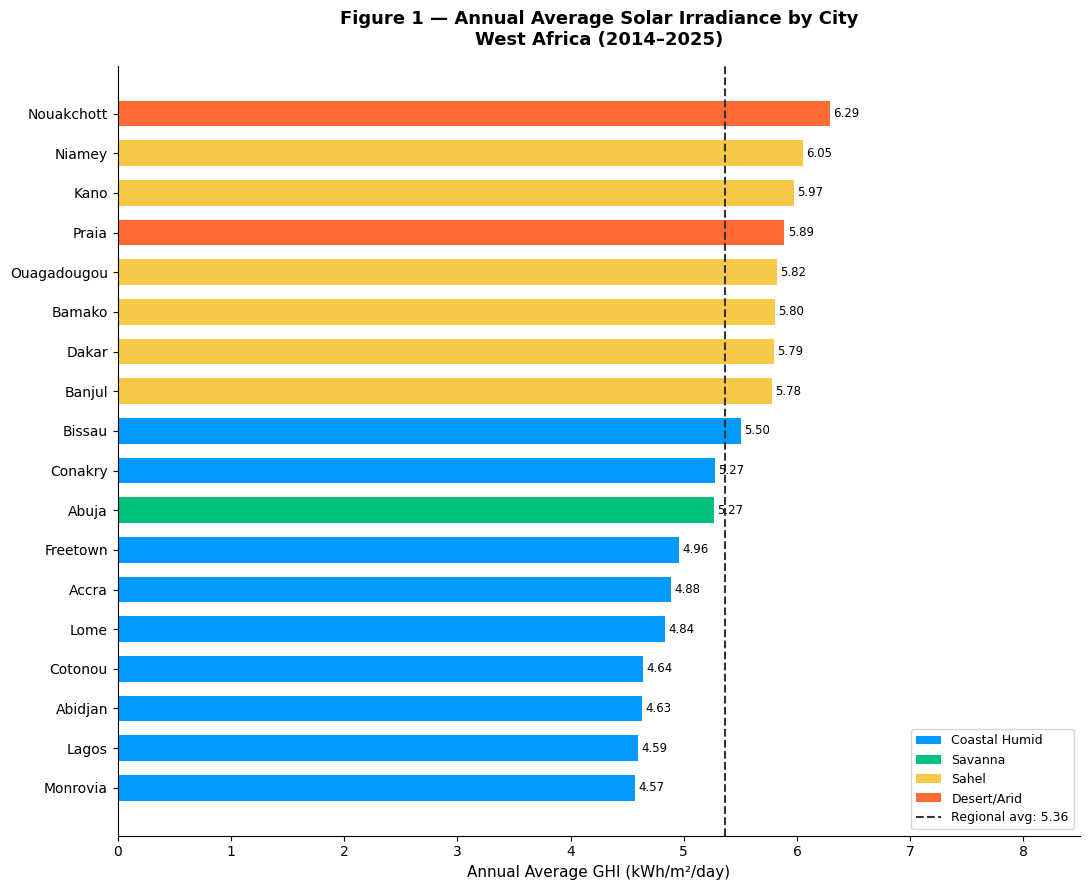

Figure 1 saved!


In [20]:
# ================================================
# FIGURE 1 — City Solar Potential Ranking Map
# Horizontal bar chart ranked by Mean GHI
# ================================================
city_ranked = city_analysis.reset_index().sort_values('Mean GHI', ascending=True)

zone_colors = {
    'Coastal Humid': '#0099ff',
    'Savanna':       '#00c27c',
    'Sahel':         '#f7c948',
    'Desert/Arid':   '#ff6b35'
}

colors = [zone_colors[z] for z in city_ranked['Climate_Zone']]

fig, ax = plt.subplots(figsize=(11, 9))

bars = ax.barh(
    city_ranked['City'],
    city_ranked['Mean GHI'],
    color=colors,
    edgecolor='none',
    height=0.65
)

# Value labels
for bar, val in zip(bars, city_ranked['Mean GHI']):
    ax.text(val + 0.03, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8.5)

# Regional average line
regional_avg = master_df['GHI'].mean()
ax.axvline(x=regional_avg, color='#333333', linestyle='--',
           linewidth=1.5, label=f'Regional average: {regional_avg:.2f} kWh/m²/day')

ax.set_title('Figure 1 — Annual Average Solar Irradiance by City\nWest Africa (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Annual Average GHI (kWh/m²/day)', fontsize=11)
ax.set_xlim(0, 8.5)
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=z) for z, c in zone_colors.items()]
legend_elements.append(plt.Line2D([0], [0], color='#333333', linestyle='--', label=f'Regional avg: {regional_avg:.2f}'))
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('../reports/fig1_city_solar_ranking.png', dpi=300)
plt.show()
print("Figure 1 saved!")

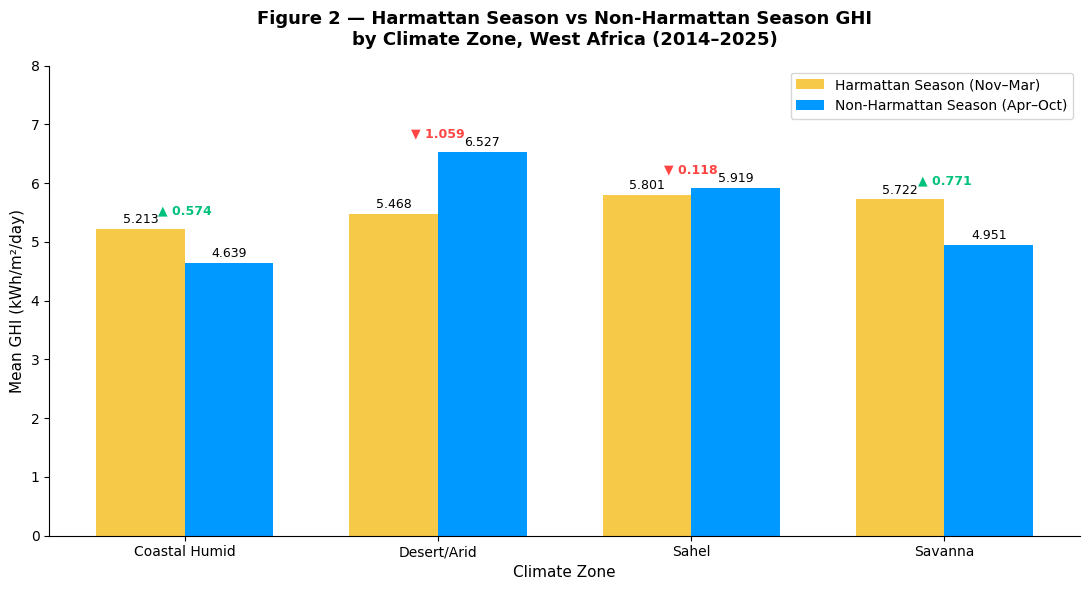

Figure 2 saved!


In [21]:
# ================================================
# FIGURE 2 — Harmattan Effect by Climate Zone
# ================================================
harmattan_plot = harmattan_analysis.reset_index()

x = np.arange(len(harmattan_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2, harmattan_plot['Harmattan'], width,
               label='Harmattan Season (Nov–Mar)',
               color='#f7c948', edgecolor='none')
bars2 = ax.bar(x + width/2, harmattan_plot['Non-Harmattan'], width,
               label='Non-Harmattan Season (Apr–Oct)',
               color='#0099ff', edgecolor='none')

# Value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Annotate GHI difference
for i, row in harmattan_plot.iterrows():
    diff = row['GHI Difference']
    color = '#00c27c' if diff > 0 else '#ff4444'
    symbol = '▲' if diff > 0 else '▼'
    ax.annotate(
        f'{symbol} {abs(diff):.3f}',
        xy=(i, max(row['Harmattan'], row['Non-Harmattan']) + 0.25),
        ha='center', fontsize=9, color=color, fontweight='bold'
    )

ax.set_title('Figure 2 — Harmattan Season vs Non-Harmattan Season GHI\nby Climate Zone, West Africa (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Climate Zone', fontsize=11)
ax.set_ylabel('Mean GHI (kWh/m²/day)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(harmattan_plot['Climate_Zone'], fontsize=10)
ax.set_ylim(0, 8)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/fig2_harmattan_effect.png', dpi=300)
plt.show()
print("Figure 2 saved!")

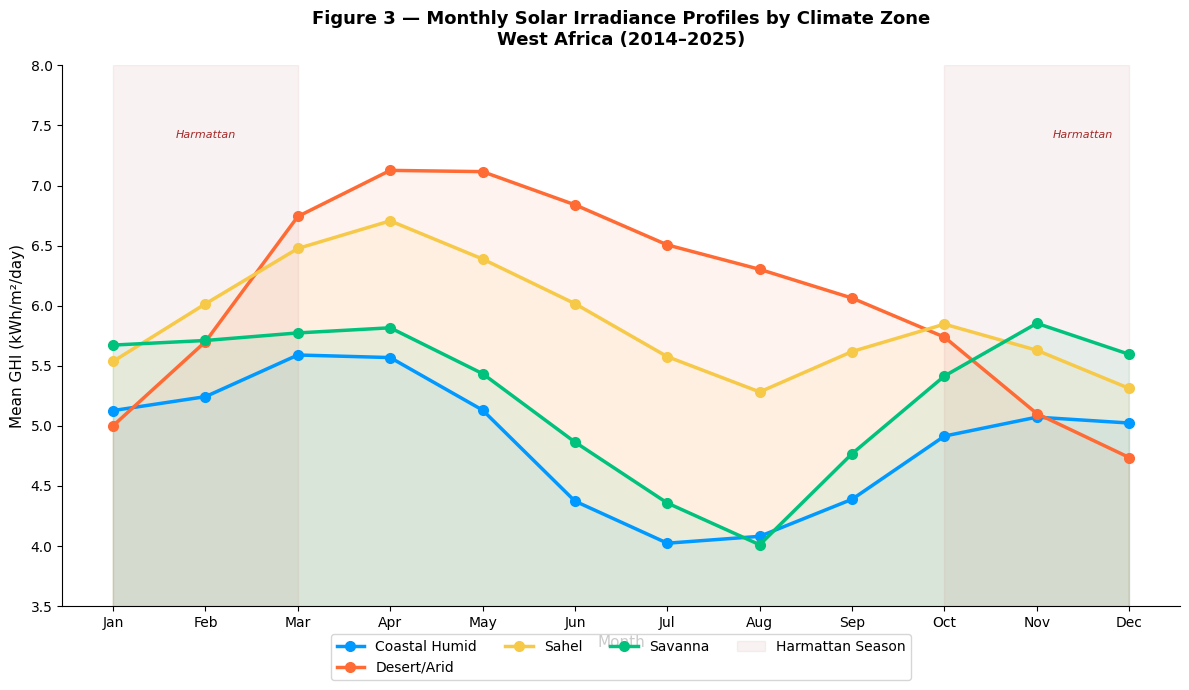

Figure 3 saved!


In [22]:
# ================================================
# FIGURE 3 — Monthly GHI Profiles by Climate Zone
# ================================================
monthly_zone = master_df.groupby(
    ['Climate_Zone', 'Month'])['GHI'].mean().reset_index()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

zone_colors_line = {
    'Coastal Humid': '#0099ff',
    'Savanna':       '#00c27c',
    'Sahel':         '#f7c948',
    'Desert/Arid':   '#ff6b35'
}

fig, ax = plt.subplots(figsize=(12, 7))

for zone in monthly_zone['Climate_Zone'].unique():
    zone_data = monthly_zone[monthly_zone['Climate_Zone'] == zone]
    ax.plot(
        month_names,
        zone_data['GHI'].values,
        marker='o',
        linewidth=2.5,
        markersize=7,
        label=zone,
        color=zone_colors_line[zone]
    )
    ax.fill_between(
        month_names,
        zone_data['GHI'].values,
        alpha=0.08,
        color=zone_colors_line[zone]
    )

# Shade Harmattan season
ax.axvspan(0, 2, alpha=0.06, color='brown', label='Harmattan Season')
ax.axvspan(9, 11, alpha=0.06, color='brown')
ax.text(1, 7.4, 'Harmattan', ha='center', fontsize=8,
        color='brown', style='italic')
ax.text(10.5, 7.4, 'Harmattan', ha='center', fontsize=8,
        color='brown', style='italic')

ax.set_title('Figure 3 — Monthly Solar Irradiance Profiles by Climate Zone\nWest Africa (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean GHI (kWh/m²/day)', fontsize=11)
ax.set_ylim(3.5, 8)
ax.legend(fontsize=10, loc='lower center',
          bbox_to_anchor=(0.5, -0.15), ncol=4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/fig3_monthly_profiles_by_zone.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure 3 saved!")

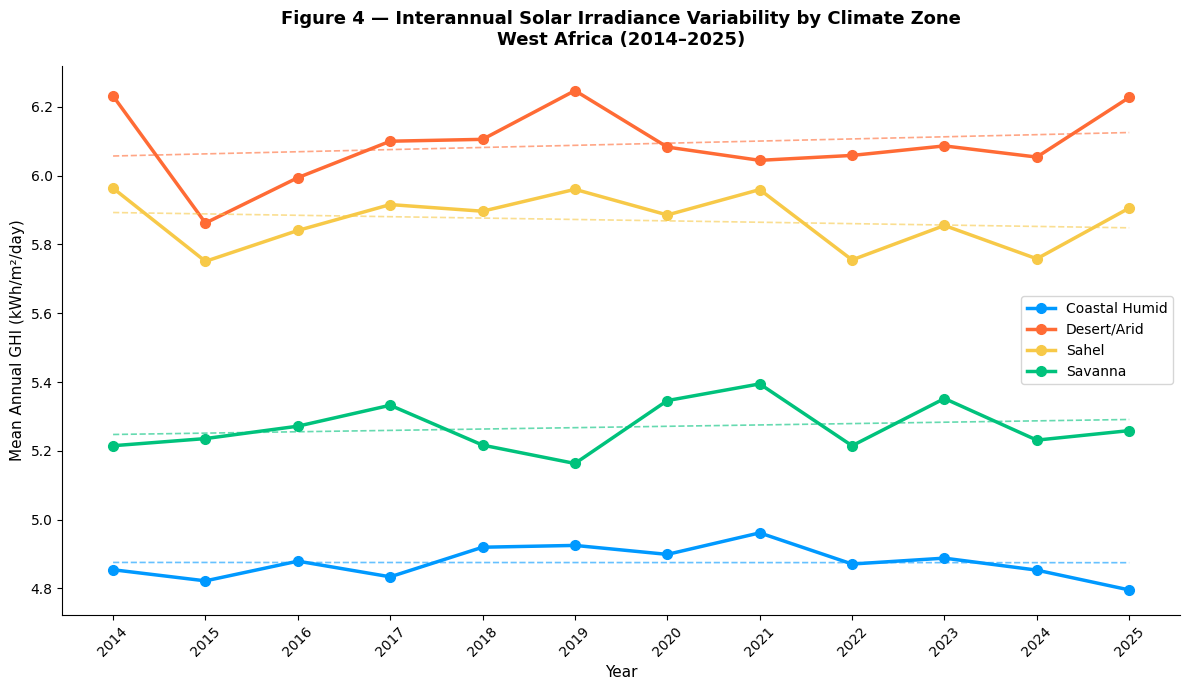

Figure 4 saved!


In [23]:
# ================================================
# FIGURE 4 — Interannual GHI Variability by Zone
# ================================================
annual_zone = master_df.groupby(
    ['Climate_Zone', 'Year'])['GHI'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

for zone in annual_zone['Climate_Zone'].unique():
    zone_data = annual_zone[annual_zone['Climate_Zone'] == zone]
    ax.plot(
        zone_data['Year'],
        zone_data['GHI'],
        marker='o',
        linewidth=2.5,
        markersize=7,
        label=zone,
        color=zone_colors_line[zone]
    )
    # Add trend line
    z = np.polyfit(zone_data['Year'], zone_data['GHI'], 1)
    p = np.poly1d(z)
    ax.plot(
        zone_data['Year'],
        p(zone_data['Year']),
        linestyle='--',
        linewidth=1.2,
        alpha=0.6,
        color=zone_colors_line[zone]
    )

ax.set_title('Figure 4 — Interannual Solar Irradiance Variability by Climate Zone\nWest Africa (2014–2025)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean Annual GHI (kWh/m²/day)', fontsize=11)
ax.set_xticks(range(2014, 2026))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/fig4_interannual_variability.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure 4 saved!")

In [25]:
import subprocess
subprocess.run(['pip', 'install', 'scipy', 'pymannkendall'])

CompletedProcess(args=['pip', 'install', 'scipy', 'pymannkendall'], returncode=0)

In [26]:
from scipy import stats

# 1. Mann-Whitney U test — Harmattan vs Non-Harmattan GHI per zone
for zone in master_df['Climate_Zone'].unique():
    zone_data = master_df[master_df['Climate_Zone'] == zone]
    harmattan = zone_data[zone_data['Season'] == 'Harmattan']['GHI']
    non_harmattan = zone_data[zone_data['Season'] == 'Non-Harmattan']['GHI']
    stat, p = stats.mannwhitneyu(harmattan, non_harmattan, 
                                  alternative='two-sided')
    print(f"{zone}: U={stat:.1f}, p={p:.4f}")

# 2. Kruskal-Wallis test — GHI differences across climate zones
zones = [master_df[master_df['Climate_Zone']==z]['GHI'].values 
         for z in master_df['Climate_Zone'].unique()]
stat, p = stats.kruskal(*zones)
print(f"\nKruskal-Wallis across zones: H={stat:.2f}, p={p:.6f}")

# 3. Mann-Kendall trend test for interannual variability
# pip install pymannkendall
import pymannkendall as mk
for zone in master_df['Climate_Zone'].unique():
    annual = master_df[master_df['Climate_Zone']==zone].groupby('Year')['GHI'].mean()
    result = mk.original_test(annual)
    print(f"{zone}: trend={result.trend}, p={result.p:.4f}, "
          f"slope={result.slope:.4f}")

Coastal Humid: U=309551.5, p=0.0000
Savanna: U=4247.5, p=0.0000
Sahel: U=79881.5, p=0.0091
Desert/Arid: U=3092.5, p=0.0000

Kruskal-Wallis across zones: H=1021.77, p=0.000000
Coastal Humid: trend=no trend, p=1.0000, slope=0.0006
Savanna: trend=no trend, p=0.4507, slope=0.0036
Sahel: trend=no trend, p=0.6312, slope=-0.0033
Desert/Arid: trend=no trend, p=0.8370, slope=0.0032


In [27]:
import subprocess
subprocess.run(['pip', 'install', 'geopandas', 'mapclassify'])

CompletedProcess(args=['pip', 'install', 'geopandas', 'mapclassify'], returncode=0)

In [28]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# City coordinates and annual average GHI
city_ghi = master_df.groupby(['City', 'Country', 'Climate_Zone'])['GHI'].mean().reset_index()
city_ghi.columns = ['City', 'Country', 'Climate_Zone', 'Mean_GHI']
city_ghi = city_ghi.round(3)

# Add coordinates
coords = {
    'Lagos':        (3.3792,   6.5244),
    'Abuja':        (7.3986,   9.0765),
    'Kano':         (8.5920,  12.0022),
    'Accra':        (-0.1870,  5.6037),
    'Dakar':        (-17.4677, 14.7167),
    'Abidjan':      (-4.0083,  5.3600),
    'Bamako':       (-8.0029, 12.6392),
    'Ouagadougou':  (-1.5332, 12.3647),
    'Niamey':       (2.1098,  13.5137),
    'Conakry':      (-13.5784, 9.6412),
    'Lome':         (1.2123,   6.1375),
    'Cotonou':      (2.4183,   6.3654),
    'Freetown':     (-13.2317, 8.4657),
    'Monrovia':     (-10.7605, 6.2907),
    'Nouakchott':   (-15.9582, 18.0735),
    'Banjul':       (-16.5790, 13.4549),
    'Bissau':       (-15.5977, 11.8636),
    'Praia':        (-23.5133, 14.9331),
}

city_ghi['lon'] = city_ghi['City'].map(lambda c: coords[c][0])
city_ghi['lat'] = city_ghi['City'].map(lambda c: coords[c][1])

# Convert to GeoDataFrame
gdf_cities = gpd.GeoDataFrame(
    city_ghi,
    geometry=gpd.points_from_xy(city_ghi['lon'], city_ghi['lat']),
    crs='EPSG:4326'
)

print("Cities GeoDataFrame created successfully")
print(gdf_cities[['City', 'Mean_GHI', 'Climate_Zone']].to_string(index=False))

Cities GeoDataFrame created successfully
       City  Mean_GHI  Climate_Zone
    Abidjan     4.630 Coastal Humid
      Abuja     5.269       Savanna
      Accra     4.884 Coastal Humid
     Bamako     5.805         Sahel
     Banjul     5.776         Sahel
     Bissau     5.503 Coastal Humid
    Conakry     5.273 Coastal Humid
    Cotonou     4.642 Coastal Humid
      Dakar     5.794         Sahel
   Freetown     4.957 Coastal Humid
       Kano     5.973         Sahel
      Lagos     4.592 Coastal Humid
       Lome     4.837 Coastal Humid
   Monrovia     4.567 Coastal Humid
     Niamey     6.052         Sahel
 Nouakchott     6.291   Desert/Arid
Ouagadougou     5.822         Sahel
      Praia     5.889   Desert/Arid


In [30]:
# Save to your data folder
tmpfile = '../data/countries.geojson'
with open(tmpfile, 'w') as f:
    f.write(response.text)

# Load and filter West Africa
world = gpd.read_file(tmpfile)

west_african_countries = [
    'Nigeria', 'Ghana', 'Senegal', 'Ivory Coast', 'Mali',
    'Burkina Faso', 'Niger', 'Guinea', 'Togo', 'Benin',
    'Sierra Leone', 'Liberia', 'Mauritania', 'Gambia',
    'Guinea-Bissau', 'Cape Verde'
]

wa_map = world[world['NAME'].isin(west_african_countries)]
print(f"Countries in map: {len(wa_map)}")
print(wa_map['NAME'].tolist())

Countries in map: 14
['Togo', 'Sierra Leone', 'Senegal', 'Nigeria', 'Niger', 'Mauritania', 'Mali', 'Liberia', 'Guinea-Bissau', 'Guinea', 'Ghana', 'Gambia', 'Burkina Faso', 'Benin']


In [31]:
# Find exact names
print(world[world['NAME'].str.contains('Ivoire|Ivory|Cote', case=False)]['NAME'].values)
print(world[world['NAME'].str.contains('Cape|Verde|Cabo', case=False)]['NAME'].values)

<StringArray>
['Côte d'Ivoire']
Length: 1, dtype: str
<StringArray>
['Cabo Verde']
Length: 1, dtype: str


In [32]:
west_african_countries = [
    'Nigeria', 'Ghana', 'Senegal', "Côte d'Ivoire", 'Mali',
    'Burkina Faso', 'Niger', 'Guinea', 'Togo', 'Benin',
    'Sierra Leone', 'Liberia', 'Mauritania', 'Gambia',
    'Guinea-Bissau', 'Cabo Verde'
]

wa_map = world[world['NAME'].isin(west_african_countries)]
print(f"Countries in map: {len(wa_map)}")
print(wa_map['NAME'].tolist())

Countries in map: 16
['Togo', 'Sierra Leone', 'Senegal', 'Nigeria', 'Niger', 'Mauritania', 'Mali', 'Liberia', 'Guinea-Bissau', 'Guinea', 'Ghana', 'Gambia', "Côte d'Ivoire", 'Cabo Verde', 'Burkina Faso', 'Benin']


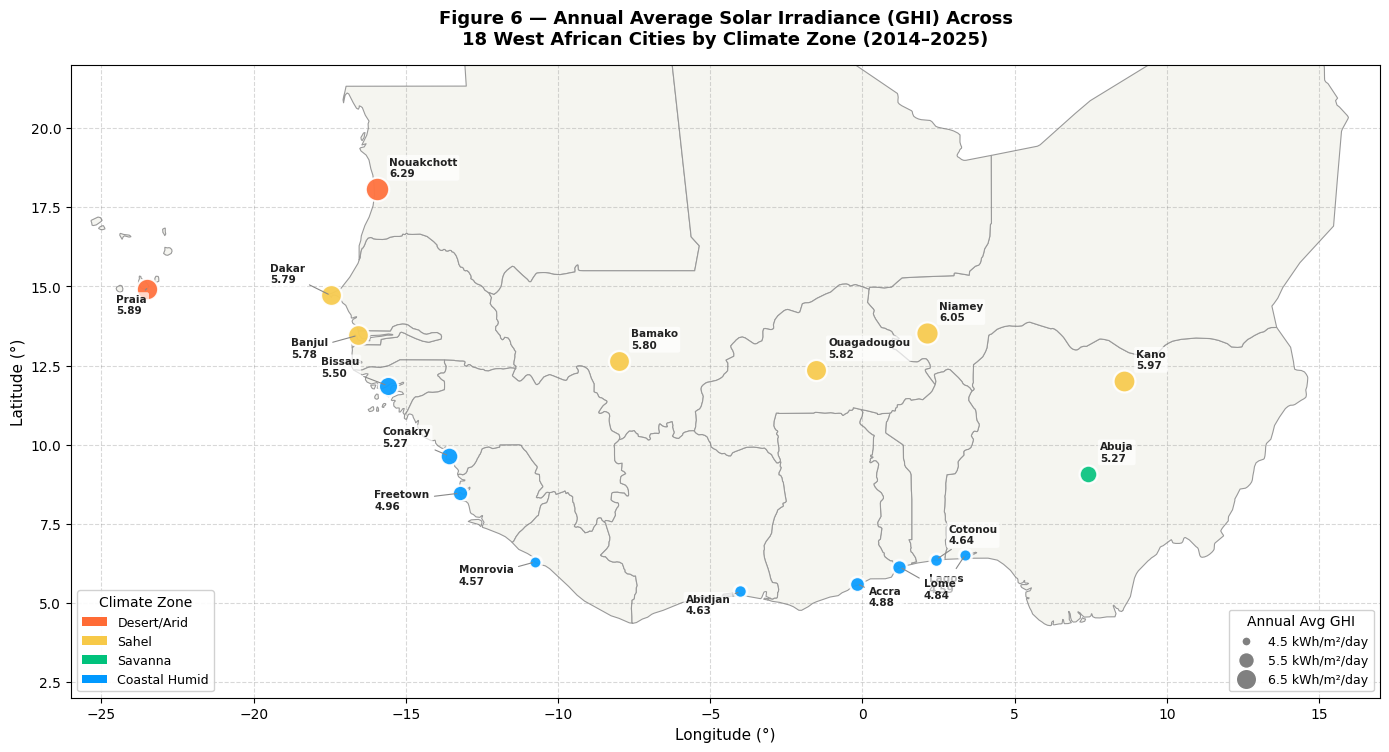

Figure 6 saved!


In [35]:
# ================================================
# FIGURE 6 — Spatial GHI Map — West Africa
# ================================================

zone_colors_map = {
    'Coastal Humid': '#0099ff',
    'Savanna':       '#00c27c',
    'Sahel':         '#f7c948',
    'Desert/Arid':   '#ff6b35'
}

fig, ax = plt.subplots(figsize=(14, 12))

# Plot country boundaries
wa_map.plot(ax=ax, color='#f5f5f0', edgecolor='#999999',
            linewidth=0.8, zorder=1)

# Plot city points sized by GHI value
for _, row in gdf_cities.iterrows():
    color = zone_colors_map[row['Climate_Zone']]
    size = (row['Mean_GHI'] - 4.0) * 120

    # Shadow circle for depth
    ax.scatter(row['lon'], row['lat'],
               s=size + 40, color='white',
               zorder=2, alpha=0.6)

    # Main circle
    ax.scatter(row['lon'], row['lat'],
               s=size, color=color,
               edgecolors='white', linewidth=1.2,
               zorder=3, alpha=0.9)

    # City label
    offset_x = 0.4
    offset_y = 0.4

    # Adjust specific labels to avoid overlap
    label_offsets = {
        'Lagos':    (-1.2, -1.2),
        'Accra':    (0.4, -0.7),
        'Lome':     (0.8, -1.0),
        'Cotonou':  (0.4,  0.5),
        'Abidjan':  (-1.8, -0.7),
        'Conakry':  (-2.2,  0.3),
        'Freetown': (-2.8, -0.5),
        'Monrovia': (-2.5, -0.7),
        'Bissau':   (-2.2,  0.3),
        'Banjul':   (-2.2, -0.7),
        'Dakar':    (-2.0,  0.4),
        'Praia':    (-1.0, -0.8),
    }

    ox, oy = label_offsets.get(row['City'], (0.4, 0.4))

    ax.annotate(
        f"{row['City']}\n{row['Mean_GHI']:.2f}",
        xy=(row['lon'], row['lat']),
        xytext=(row['lon'] + ox, row['lat'] + oy),
        fontsize=7.5,
        fontweight='bold',
        color='#222222',
        zorder=5,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                  alpha=0.7, edgecolor='none'),
        arrowprops=dict(arrowstyle='-', color='#888888',
                        lw=0.8) if (ox, oy) != (0.4, 0.4) else None
    )

# Legend — climate zones
legend_elements = [
    Patch(facecolor=zone_colors_map['Desert/Arid'],
          label='Desert/Arid'),
    Patch(facecolor=zone_colors_map['Sahel'],
          label='Sahel'),
    Patch(facecolor=zone_colors_map['Savanna'],
          label='Savanna'),
    Patch(facecolor=zone_colors_map['Coastal Humid'],
          label='Coastal Humid'),
]

# Legend — circle sizes
size_legend = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt((4.5-4.0)*120/np.pi)*1.5,
           label='4.5 kWh/m²/day'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt((5.5-4.0)*120/np.pi)*1.5,
           label='5.5 kWh/m²/day'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='gray',
           markersize=np.sqrt((6.5-4.0)*120/np.pi)*1.5,
           label='6.5 kWh/m²/day'),
]

leg1 = ax.legend(handles=legend_elements,
                 title='Climate Zone',
                 loc='lower left',
                 fontsize=9,
                 title_fontsize=10,
                 framealpha=0.9)

leg2 = ax.legend(handles=size_legend,
                 title='Annual Avg GHI',
                 loc='lower right',
                 fontsize=9,
                 title_fontsize=10,
                 framealpha=0.9)

ax.add_artist(leg1)

# Map extent
ax.set_xlim(-26, 17)
ax.set_ylim(2, 22)

# Gridlines
ax.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_xlabel('Longitude (°)', fontsize=11)
ax.set_ylabel('Latitude (°)', fontsize=11)

ax.set_title(
    'Figure 6 — Annual Average Solar Irradiance (GHI) Across\n'
    '18 West African Cities by Climate Zone (2014–2025)',
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('../reports/fig6_spatial_ghi_map.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("Figure 6 saved!")